## Install Packages

In [1]:
!pip install datasets evaluate gradio huggingface_hub peft bitsandbytes transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [18]:
import warnings
warnings.filterwarnings("ignore")

## Imports

In [19]:
# Fine-tuning LLMs for Text-to-SQL with LoRA and QLoRA
import os
import json
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig
)
from peft import (
    prepare_model_for_kbit_training,
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel,
    PeftConfig
)
import evaluate
from sklearn.model_selection import train_test_split
import gradio as gr

## Set Device

In [20]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Model Names and HF Token

In [ ]:
# Define the models to fine-tune
MODEL1_NAME = "meta-llama/Llama-3.2-1B"    # Replace with your preferred Llama 3 variant
MODEL2_NAME = "mistralai/Mistral-7B-Instruct-v0.3" # Replace with the Mistral model you want to use

# You'll need a Hugging Face token to access these models
HF_TOKEN = "YOUR HF TOKEN"  # Replace with your actual token

## Load and Preprocess data

In [22]:
# Function to load and preprocess the dataset
def load_and_preprocess_data():
    print("Loading the Gretel synthetic text-to-SQL dataset...")
    dataset = load_dataset("gretelai/synthetic_text_to_sql")

    # Inspect the dataset structure
    print(f"Dataset structure: {dataset}")

    # Prepare training data
    def prepare_training_data(examples):
        # Format: Given schema context and natural language query, generate SQL and explanation
        prompts = []
        completions = []

        for sql_context, sql_prompt, sql, sql_explanation in zip(
            examples["sql_context"],
            examples["sql_prompt"],
            examples["sql"],
            examples["sql_explanation"]
        ):
            # Input format with schema context and query
            prompt = f"""### Schema:
{sql_context}

### Query:
{sql_prompt}

### SQL:"""

            # Output format with SQL and explanation
            completion = f"""{sql}

### Explanation:
{sql_explanation}"""

            prompts.append(prompt)
            completions.append(completion)

        return {"prompt": prompts, "completion": completions}

    # Apply preprocessing
    processed_dataset = dataset.map(
        prepare_training_data,
        batched=True,
        remove_columns=dataset["train"].column_names
    )

    # Split into train and eval sets if needed
    if "test" not in processed_dataset:
        split_dataset = processed_dataset["train"].train_test_split(test_size=0.1, seed=42)
    else:
        split_dataset = {
            "train": processed_dataset["train"],
            "test": processed_dataset["test"]
        }

    return split_dataset

## Tokenize data for training

In [23]:
# Function to tokenize the dataset for training
def tokenize_dataset_for_training(dataset_dict, tokenizer, max_length=512):
    def tokenize(examples):
        # Combine prompt and completion for causal language modeling
        texts = [prompt + completion for prompt, completion in zip(examples["prompt"], examples["completion"])]

        result = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding="max_length"
        )

        # Set labels to be the same as input_ids for causal LM training
        result["labels"] = result["input_ids"].copy()
        return result

    # Apply tokenization to both train and test datasets
    tokenized_datasets = {}
    for split, dataset in dataset_dict.items():
        tokenized_datasets[split] = dataset.map(tokenize, batched=True, remove_columns=["prompt", "completion"])

    return tokenized_datasets

## Fine Tuning with LoRA

In [24]:
# Function to fine-tune with LoRA
def finetune_with_lora(model_name, dataset, output_dir):
    print(f"Fine-tuning {model_name} with LoRA...")

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="right")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None
    )

    # Tokenize dataset
    tokenized_dataset = tokenize_dataset_for_training(dataset, tokenizer)

    # Configure LoRA - target modules vary by model architecture
    if "gpt2" in model_name:
        target_modules = ["c_attn", "c_proj"]  # GPT-2 specific attention modules
    else:
        target_modules = ["q_proj", "v_proj"]  # Default for many transformer models

    lora_config = LoraConfig(
        r=16,                       # Rank - controls capacity and parameter count
        lora_alpha=32,              # Alpha parameter for scaling
        target_modules=target_modules,  # Which modules to apply LoRA to
        lora_dropout=0.05,          # Dropout probability for regularization
        bias="none",                # Whether to train bias parameters
        task_type=TaskType.CAUSAL_LM  # Task type
    )

    # Prepare model with LoRA
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()  # Shows parameter efficiency

    # Training arguments - adjust based on available hardware
    batch_size = 2 if torch.cuda.is_available() else 1
    gradient_accumulation_steps = 4 if torch.cuda.is_available() else 8

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=3e-4,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=3,
        weight_decay=0.01,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        push_to_hub=False,
        gradient_accumulation_steps=gradient_accumulation_steps,
        fp16=torch.cuda.is_available(),
    )

    # Create data collator
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False  # Not using masked language modeling
    )

    # Create trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        data_collator=data_collator,
    )

    # Train the model
    trainer.train()

    # Save the fine-tuned model
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    return model, tokenizer, trainer

## Evaluate Model

In [25]:
# Function to evaluate model performance on SQL generation
def evaluate_model(model, tokenizer, dataset, model_name, is_finetuned=False):
    print(f"Evaluating {'fine-tuned' if is_finetuned else 'base'} {model_name} model...")

    # Set up metrics
    exact_match = evaluate.load("exact_match")

    # Track predictions and references
    all_predictions = []
    all_references = []

    # Set model to evaluation mode
    model.eval()

    # Process examples from test set
    for idx, example in enumerate(dataset["test"]):
        if idx >= 50:  # Limit evaluation to 50 examples for speed
            break

        # Format input for generation
        input_text = example["prompt"]
        reference_text = example["completion"]

        # Get SQL portion from reference (extract just the SQL statement before the explanation)
        reference_sql = reference_text.split("### Explanation:")[0].strip()

        # Tokenize input
        inputs = tokenizer(input_text, return_tensors="pt").to(device)

        # Generate output
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=False,
                num_beams=4,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.pad_token_id
            )

        # Decode generated text
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract SQL (if there's an explanation section, extract only the SQL)
        if "### Explanation:" in generated_text:
            generated_sql = generated_text.split("### Explanation:")[0].replace(input_text, "").strip()
        else:
            # Otherwise take all generated output
            generated_sql = generated_text.replace(input_text, "").strip()

        # Add to results
        all_predictions.append(generated_sql)
        all_references.append(reference_sql)

    # Calculate metrics
    exact_match_score = exact_match.compute(predictions=all_predictions, references=all_references)

    # Calculate a simple character-level similarity score (simple proxy for SQL correctness)
    similarity_scores = []
    for pred, ref in zip(all_predictions, all_references):
        # Normalize whitespace and case for comparison
        pred_norm = " ".join(pred.lower().split())
        ref_norm = " ".join(ref.lower().split())

        # Simple character overlap score
        max_len = max(len(pred_norm), len(ref_norm))
        if max_len == 0:
            similarity_scores.append(0.0)
        else:
            # Count matching characters
            matches = sum(1 for a, b in zip(pred_norm, ref_norm) if a == b)
            similarity_scores.append(matches / max_len)

    avg_similarity = sum(similarity_scores) / len(similarity_scores) if similarity_scores else 0

    results = {
        "model_name": model_name,
        "fine_tuned": is_finetuned,
        "exact_match": exact_match_score["exact_match"],
        "avg_char_similarity": avg_similarity,
        "num_samples": len(all_predictions)
    }

    print(f"Evaluation results: {results}")
    return results

## Evaluate Base Models

In [26]:
# Function to evaluate base models (optional, memory intensive)
def evaluate_base_models(model_names, dataset):
    results = []

    for model_name in model_names:
        print(f"Loading base model: {model_name}")
        try:
            # Load tokenizer
            tokenizer = AutoTokenizer.from_pretrained(
                model_name,
                use_auth_token=HF_TOKEN
            )
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token

            # Load model with 8-bit quantization to save memory
            model = AutoModelForCausalLM.from_pretrained(
                model_name,
                device_map="auto",
                load_in_8bit=True,  # Use 8-bit to fit in memory
                use_auth_token=HF_TOKEN
            )

            # Evaluate
            result = evaluate_model(model, tokenizer, dataset, model_name, is_finetuned=False)
            results.append(result)
        except Exception as e:
            print(f"Error evaluating base model {model_name}: {e}")

    return results

## Evaluate Fine Tuned Models

In [27]:
# Function to load and evaluate fine-tuned models
def evaluate_finetuned_models(output_dirs, model_names, dataset):
    results = []

    for model_name, output_dir in zip(model_names, output_dirs):
        print(f"Loading fine-tuned model: {model_name} from {output_dir}")
        try:
            # Load config
            config = PeftConfig.from_pretrained(output_dir)

            # Load base model with 8-bit quantization
            model = AutoModelForCausalLM.from_pretrained(
                config.base_model_name_or_path,
                device_map="auto",
                load_in_8bit=True,  # Use 8-bit to fit in memory
                use_auth_token=HF_TOKEN
            )

            # Load tokenizer
            tokenizer = AutoTokenizer.from_pretrained(output_dir)

            # Load adapter
            model = PeftModel.from_pretrained(model, output_dir)

            # Evaluate
            result = evaluate_model(model, tokenizer, dataset, model_name, is_finetuned=True)
            results.append(result)
        except Exception as e:
            print(f"Error evaluating fine-tuned model {model_name}: {e}")
            results.append({
                "model_name": model_name,
                "fine_tuned": True,
                "exact_match": 0.0,
                "avg_char_similarity": 0.0,
                "num_samples": 0,
                "error": str(e)
            })

    return results

## Create UI

In [56]:
# Function to create UI for querying models
def create_ui(model1, tokenizer1, model2, tokenizer2):
    def generate_sql(schema, query, model_choice):
        # Prepare input
        input_text = f"""### Schema:
{schema}

### Query:
{query}

### SQL:"""

        # Choose model and tokenizer based on selection
        if model_choice == "Llama 3":
            model, tokenizer = model1, tokenizer1
        else:
            model, tokenizer = model2, tokenizer2

        # Tokenize
        inputs = tokenizer(input_text, return_tensors="pt").to(device)

        # Generate
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.pad_token_id
            )

        # Decode
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract SQL and explanation
        result = generated_text.replace(input_text, "")

        # Split into SQL and explanation if possible
        if "### Explanation:" in result:
            sql, explanation = result.split("### Explanation:", 1)
            return sql.strip(), explanation.strip()
        else:
            return result.strip(), "No explanation generated."

    # Create Gradio interface
    schema_input = gr.Textbox(
        lines=10,
        placeholder="Enter the database schema here...",
        label="Database Schema"
    )

    query_input = gr.Textbox(
        lines=3,
        placeholder="Enter your natural language query here...",
        label="Natural Language Query"
    )

    model_choice = gr.Radio(
        ["Llama 3", "Mistral"],
        label="Select Model",
        value="Llama 3"
    )

    sql_output = gr.Textbox(
        lines=5,
        label="Generated SQL"
    )

    explanation_output = gr.Textbox(
        lines=5,
        label="Explanation"
    )

    gr.Interface(
        fn=generate_sql,
        inputs=[schema_input, query_input, model_choice],
        outputs=[sql_output, explanation_output],
        title="Text to SQL Generator: Base Model Evaluator",
        description="Enter a database schema and natural language query to generate SQL.",
        examples = [
            [
                "CREATE TABLE employees (id INTEGER PRIMARY KEY, name TEXT, department TEXT, salary INTEGER);",
                "Show me all employees in the Engineering department earning more than 100000",
                model_names[0] if model_names else None
            ],
            [
                "CREATE TABLE products (id INTEGER PRIMARY KEY, name TEXT, category TEXT, price REAL, inventory INTEGER);\nCREATE TABLE sales (id INTEGER PRIMARY KEY, product_id INTEGER, date DATE, quantity INTEGER, FOREIGN KEY(product_id) REFERENCES products(id));",
                "List all products in the Electronics category with less than 10 items in inventory",
                model_names[0] if model_names else None
            ],
            [
                "CREATE TABLE customers (id INTEGER PRIMARY KEY, name TEXT, region TEXT);\nCREATE TABLE purchases (id INTEGER PRIMARY KEY, customer_id INTEGER, amount REAL, date DATE, FOREIGN KEY(customer_id) REFERENCES customers(id));",
                "Rank customers by total purchase amount within each region",
                model_names[0] if model_names else None
            ]
        ]
    ).launch(share=True)

## Fine Tune with Q-LoRA

In [29]:
# Function to fine-tune with QLoRA (Quantized LoRA)
def finetune_with_qlora(model_name, dataset, output_dir):
    print(f"Fine-tuning {model_name} with QLoRA...")

    # Skip QLoRA if not on CUDA - quantization requires GPU
    if not torch.cuda.is_available():
        print("QLoRA requires CUDA. Skipping QLoRA fine-tuning.")
        return None, None

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        padding_side="right",
        use_auth_token=HF_TOKEN
    )

    # Set padding token if needed
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Configure 4-bit quantization
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,  # Use double quantization for further memory savings
        bnb_4bit_quant_type="nf4",       # Normalized float 4 quantization
        bnb_4bit_compute_dtype=torch.float16  # Compute in fp16
    )

    # Load model with quantization
    try:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=bnb_config,
            device_map="auto",
            use_auth_token=HF_TOKEN
        )
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, None

    # Prepare model for k-bit training
    model = prepare_model_for_kbit_training(model)

    # Tokenize dataset
    tokenized_dataset = tokenize_dataset_for_training(dataset, tokenizer)

    # Configure LoRA for different model architectures
    if "llama" in model_name.lower():
        # Target modules for Llama models
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    elif "smollm" in model_name.lower():
        # Target modules for Mistral models
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    else:
        # Default target modules
        target_modules = ["query_key_value", "dense", "dense_h_to_4h", "dense_4h_to_h"]

    qlora_config = LoraConfig(
        r=16,                    # Rank
        lora_alpha=32,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.CAUSAL_LM
    )

    # Prepare model with QLoRA
    model = get_peft_model(model, qlora_config)
    model.print_trainable_parameters()

    # Training arguments - adjusted for larger models
    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=2e-4,           # Slightly lower learning rate for larger models
        per_device_train_batch_size=1, # Reduce batch size for larger models
        per_device_eval_batch_size=1,
        num_train_epochs=1,           # Fewer epochs for faster training
        weight_decay=0.01,
        evaluation_strategy="steps",   # Evaluate every n steps instead of every epoch
        eval_steps=500,
        save_strategy="steps",
        save_steps=500,
        load_best_model_at_end=True,
        push_to_hub=False,
        gradient_accumulation_steps=16, # Increased gradient accumulation to compensate for smaller batch size
        fp16=True,
        logging_steps=100,
        warmup_steps=100,
    )

    # Create data collator
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False
    )

    # Create trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        data_collator=data_collator,
    )

    # Train the model
    trainer.train()

    # Save the fine-tuned model
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)

    return model, tokenizer, trainer

## Plot and save loss curves

In [30]:
def plot_and_save_loss_curves(trainer, model_name, output_dir):
    """
    Plot training and validation loss curves based on trainer logs and save them to the output directory.

    Args:
        trainer: The Hugging Face Trainer object after training
        model_name: Name of the model being trained (for plot title)
        output_dir: Directory where to save the plot
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # Check if trainer has a log history
    if hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history') and trainer.state.log_history:
        # Extract loss values from logs
        train_losses = []
        eval_losses = []
        steps = []

        for entry in trainer.state.log_history:
            # Training loss entries
            if 'loss' in entry and 'step' in entry and 'eval_loss' not in entry:
                train_losses.append(entry['loss'])
                steps.append(entry['step'])

            # Evaluation loss entries
            if 'eval_loss' in entry:
                eval_losses.append(entry['eval_loss'])

        # Create the plot
        plt.figure(figsize=(10, 6))

        # Plot training loss
        if train_losses:
            plt.plot(steps, train_losses, label='Training Loss', color='blue', marker='o', linestyle='-', markersize=3)

        # Plot evaluation loss if available
        if eval_losses:
            # Create evenly spaced x points for eval loss
            eval_steps = np.linspace(min(steps), max(steps), len(eval_losses))
            plt.plot(eval_steps, eval_losses, label='Validation Loss', color='red', marker='s', linestyle='--', markersize=3)

        # Add labels and title
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.title(f'Training and Validation Loss for {model_name}')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)

        # Create file path
        model_short_name = model_name.split('/')[-1] if '/' in model_name else model_name
        file_path = os.path.join(output_dir, f'{model_short_name}_loss_curves.png')

        # Save the plot
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        print(f"Loss curves saved to {file_path}")

        # Show the plot
        plt.show()

        # Save loss values as CSV for further analysis
        if train_losses or eval_losses:
            import pandas as pd

            # Create a dictionary to store the data
            data = {'step': steps}

            if train_losses:
                data['train_loss'] = train_losses

            if eval_losses:
                # If eval_losses is shorter than train_losses, pad with NaN
                eval_loss_padded = eval_losses + [np.nan] * (len(steps) - len(eval_losses))
                data['eval_loss'] = eval_loss_padded

            # Create a DataFrame and save as CSV
            df = pd.DataFrame(data)
            csv_path = os.path.join(output_dir, f'{model_short_name}_loss_data.csv')
            df.to_csv(csv_path, index=False)
            print(f"Loss data saved to {csv_path}")
    else:
        print("No training logs found in trainer state.")

## Set output directories

In [31]:
# Set output directories
llama_output_dir = "./llama3_sql_model"
mistral_output_dir = "./mistral_sql_model"

# Create output directories if they don't exist
os.makedirs(llama_output_dir, exist_ok=True)
os.makedirs(mistral_output_dir, exist_ok=True)

In [32]:
# Load and preprocess the dataset
dataset = load_and_preprocess_data()

Loading the Gretel synthetic text-to-SQL dataset...
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 5851
    })
})


In [33]:
# Define model names and output directories
model_names = [MODEL1_NAME, MODEL2_NAME]
output_dirs = [llama_output_dir, mistral_output_dir]

In [34]:
# Evaluate base models before fine-tuning (skip if memory is a concern)
base_results = evaluate_base_models(model_names, dataset)

Loading base model: meta-llama/Llama-3.2-1B


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Evaluating base meta-llama/Llama-3.2-1B model...
Evaluation results: {'model_name': 'meta-llama/Llama-3.2-1B', 'fine_tuned': False, 'exact_match': 0.02, 'avg_char_similarity': 0.13152750174855854, 'num_samples': 50}
Loading base model: mistralai/Mistral-7B-Instruct-v0.3


tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Evaluating base mistralai/Mistral-7B-Instruct-v0.3 model...
Evaluation results: {'model_name': 'mistralai/Mistral-7B-Instruct-v0.3', 'fine_tuned': False, 'exact_match': 0.06, 'avg_char_similarity': 0.14494762562703448, 'num_samples': 50}


In [35]:
for data in base_results:
    print('model_name: ' + str(data['model_name']))
    print('fine_tuned: ' + str(data['fine_tuned']))
    print('exact_match: ' + str(data['exact_match']))
    print('avg_char_similarity: ' + str(data['avg_char_similarity']))
    print('num_samples: ' + str(data['num_samples']))
    print('----------------------------------------------------------')

model_name: meta-llama/Llama-3.2-1B
fine_tuned: False
exact_match: 0.02
avg_char_similarity: 0.13152750174855854
num_samples: 50
----------------------------------------------------------
model_name: mistralai/Mistral-7B-Instruct-v0.3
fine_tuned: False
exact_match: 0.06
avg_char_similarity: 0.14494762562703448
num_samples: 50
----------------------------------------------------------


## Fine Tune Llama with LoRA

Fine-tuning Llama 3 model with LoRA...
Fine-tuning meta-llama/Llama-3.2-1B with LoRA...


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5851 [00:00<?, ? examples/s]

trainable params: 1,703,936 || all params: 1,237,518,336 || trainable%: 0.1377


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shashwats538 (shashwats538-northeastern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.540100,0.552874
2,0.515600,0.530917
3,0.489800,0.518942


Loss curves saved to ./llama3_sql_model/Llama-3.2-1B_loss_curves.png


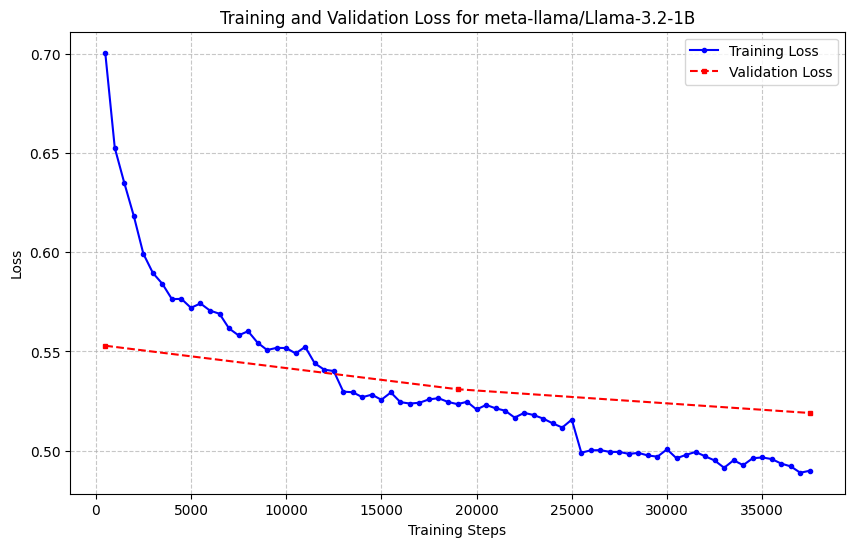

Loss data saved to ./llama3_sql_model/Llama-3.2-1B_loss_data.csv


In [36]:
# Fine-tune Llama 3 with LoRA
print("Fine-tuning Llama 3 model with LoRA...")
model1, tokenizer1, trainer1 = finetune_with_lora(MODEL1_NAME, dataset, llama_output_dir)
plot_and_save_loss_curves(trainer1, MODEL1_NAME, llama_output_dir)

## Fine Tune Mistral with Q-LoRA

Fine-tuning Mistral model with LoRA...
Fine-tuning mistralai/Mistral-7B-Instruct-v0.3 with LoRA...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5851 [00:00<?, ? examples/s]

trainable params: 6,815,744 || all params: 7,254,839,296 || trainable%: 0.0939


Epoch,Training Loss,Validation Loss
1,0.371200,0.378784
2,0.342500,0.355322
3,0.304100,0.338180


Loss curves saved to ./mistral_sql_model/Mistral-7B-Instruct-v0.3_loss_curves.png


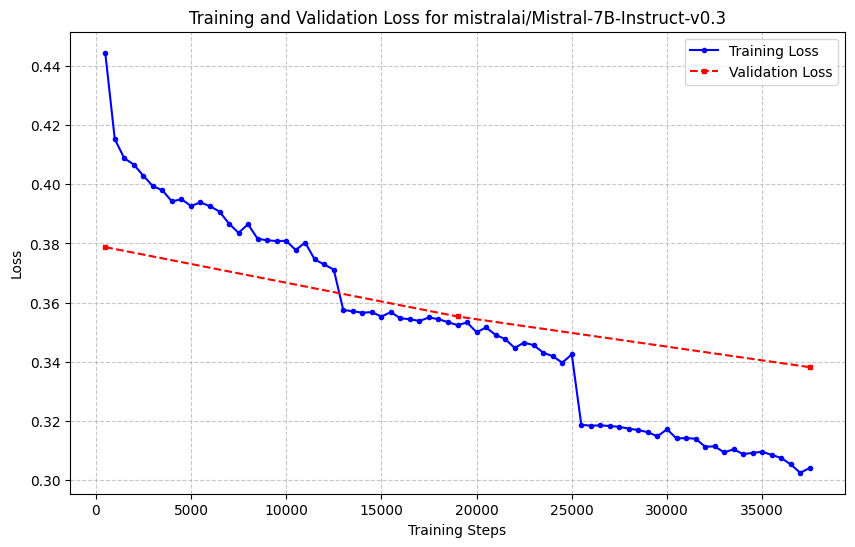

Loss data saved to ./mistral_sql_model/Mistral-7B-Instruct-v0.3_loss_data.csv


In [37]:
# Fine-tune Mistral with QLoRA
print("Fine-tuning Mistral model with LoRA...")
model2, tokenizer2, trainer2 = finetune_with_lora(MODEL2_NAME, dataset, mistral_output_dir)
plot_and_save_loss_curves(trainer2, MODEL2_NAME, mistral_output_dir)

## Evaluate Trained Models

In [45]:
# Handle the case where models couldn't be loaded
if model1 is None or model2 is None:
    print("Error: One or both models failed to load. Check your GPU memory and HF token.")

    # Evaluate fine-tuned models
finetuned_results = evaluate_finetuned_models(output_dirs, model_names, dataset)

Loading fine-tuned model: meta-llama/Llama-3.2-1B from ./llama3_sql_model


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Evaluating fine-tuned meta-llama/Llama-3.2-1B model...
Evaluation results: {'model_name': 'meta-llama/Llama-3.2-1B', 'fine_tuned': True, 'exact_match': 0.32, 'avg_char_similarity': 0.4807867596993651, 'num_samples': 50}
Loading fine-tuned model: mistralai/Mistral-7B-Instruct-v0.3 from ./mistral_sql_model


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating fine-tuned mistralai/Mistral-7B-Instruct-v0.3 model...
Evaluation results: {'model_name': 'mistralai/Mistral-7B-Instruct-v0.3', 'fine_tuned': True, 'exact_match': 0.32, 'avg_char_similarity': 0.5245928147948548, 'num_samples': 50}


In [46]:
# Compare results
print("\n=== PERFORMANCE COMPARISON ===")
if base_results:
    print("Base Models:")
    for result in base_results:
        print(f"  {result['model_name']}: Exact Match = {result['exact_match']:.4f}, Similarity = {result['avg_char_similarity']:.4f}")

print("\nFine-tuned Models:")
for result in finetuned_results:
    print(f"  {result['model_name']}: Exact Match = {result['exact_match']:.4f}, Similarity = {result['avg_char_similarity']:.4f}")


=== PERFORMANCE COMPARISON ===
Base Models:
  meta-llama/Llama-3.2-1B: Exact Match = 0.0200, Similarity = 0.1315
  mistralai/Mistral-7B-Instruct-v0.3: Exact Match = 0.0600, Similarity = 0.1449

Fine-tuned Models:
  meta-llama/Llama-3.2-1B: Exact Match = 0.3200, Similarity = 0.4808
  mistralai/Mistral-7B-Instruct-v0.3: Exact Match = 0.3200, Similarity = 0.5246


## Download Model Data

In [40]:
!zip -r llama3_sql_model.zip /content/llama3_sql_model
from google.colab import files
files.download('llama3_sql_model.zip')

  adding: content/llama3_sql_model/ (stored 0%)
  adding: content/llama3_sql_model/adapter_config.json (deflated 53%)
  adding: content/llama3_sql_model/runs/ (stored 0%)
  adding: content/llama3_sql_model/runs/Mar13_05-17-06_1f7d0d4f7ab4/ (stored 0%)
  adding: content/llama3_sql_model/runs/Mar13_05-17-06_1f7d0d4f7ab4/events.out.tfevents.1741843028.1f7d0d4f7ab4.4726.0 (deflated 66%)
  adding: content/llama3_sql_model/tokenizer.json (deflated 85%)
  adding: content/llama3_sql_model/adapter_model.safetensors (deflated 7%)
  adding: content/llama3_sql_model/special_tokens_map.json (deflated 64%)
  adding: content/llama3_sql_model/Llama-3.2-1B_loss_curves.png (deflated 17%)
  adding: content/llama3_sql_model/checkpoint-25000/ (stored 0%)
  adding: content/llama3_sql_model/checkpoint-25000/adapter_config.json (deflated 53%)
  adding: content/llama3_sql_model/checkpoint-25000/trainer_state.json (deflated 80%)
  adding: content/llama3_sql_model/checkpoint-25000/adapter_model.safetensors (defl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
!zip -r mistral_sql_model.zip /content/mistral_sql_model
from google.colab import files
files.download('mistral_sql_model.zip')

  adding: content/mistral_sql_model/ (stored 0%)
  adding: content/mistral_sql_model/adapter_config.json (deflated 53%)
  adding: content/mistral_sql_model/runs/ (stored 0%)
  adding: content/mistral_sql_model/runs/Mar13_09-11-07_1f7d0d4f7ab4/ (stored 0%)
  adding: content/mistral_sql_model/runs/Mar13_09-11-07_1f7d0d4f7ab4/events.out.tfevents.1741857068.1f7d0d4f7ab4.4726.1 (deflated 66%)
  adding: content/mistral_sql_model/tokenizer.json (deflated 85%)
  adding: content/mistral_sql_model/tokenizer.model (deflated 61%)
  adding: content/mistral_sql_model/Mistral-7B-Instruct-v0.3_loss_curves.png (deflated 16%)
  adding: content/mistral_sql_model/adapter_model.safetensors (deflated 7%)
  adding: content/mistral_sql_model/Mistral-7B-Instruct-v0.3_loss_data.csv (deflated 66%)
  adding: content/mistral_sql_model/special_tokens_map.json (deflated 73%)
  adding: content/mistral_sql_model/checkpoint-25000/ (stored 0%)
  adding: content/mistral_sql_model/checkpoint-25000/adapter_config.json (def

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Launch Comparision with Gradio UI

In [57]:
# Create UI for querying models
print("\nLaunching UI for querying models...")
create_ui(model1, tokenizer1, model2, tokenizer2)


Launching UI for querying models...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4980a7582aa4b392b0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Using device: cuda
Loading the Gretel synthetic text-to-SQL dataset...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset structure: DatasetDict({
    train: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 5851
    })
})
Skipping base model evaluation to conserve memory...
Fine-tuning Llama 3 model with QLoRA...
Fine-tuning meta-llama/Llama-3.2-1B with QLoRA...


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/tokenization_auto.py:823: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/models/auto/auto_factory.py:471: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

...

trainable params: 41,943,040 || all params: 7,289,966,592 || trainable%: 0.5754


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
500,0.397300,0.416305
1000,0.389000,0.400042
1500,0.377600,0.390990
2000,0.369800,0.408225
2500,0.363600,0.376004
3000,0.361700,0.368646
3500,0.346400,0.361428
4000,0.346500,0.355274


/usr/local/lib/python3.11/dist-packages/peft/utils/other.py:716: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-67d18037-06905b886bffb5982978f2b6;127863a9-7026-481a-939b-1c1471167839)

Cannot access gated repo for url https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3/resolve/main/config.json.
Access to model mistralai/Mistral-7B-Instruct-v0.3 is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in mistralai/Mistral-7B-Instruct-v0.3.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/utils/save_and_load.py:246: UserWarning: Could not find a config file in mistralai/Mistral-7B-Instruct-v0.3 - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explici

Step,Training Loss,Validation Loss
500,0.397300,0.416305
1000,0.389000,0.400042
1500,0.377600,0.390990
2000,0.369800,0.408225
2500,0.363600,0.376004
3000,0.361700,0.368646
3500,0.346400,0.361428
4000,0.346500,0.355274


In [ ]:
import os
import zipfile
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel, PeftConfig
import gradio as gr

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths for the two separate zip files
llama_zip_path = "/content/llama3_sql_model.zip"  # Path to your Llama model zip file
mistral_zip_path = "/content/mistral_sql_model.zip"  # Path to your Mistral model zip file

# Extraction directories
extraction_base_dir = "./extracted_models"
llama_extract_dir = os.path.join(extraction_base_dir, "llama")
mistral_extract_dir = os.path.join(extraction_base_dir, "mistral")

# Model directories (these will depend on the structure inside your zip files)
# You may need to adjust these paths after extraction
llama_model_dir = llama_extract_dir  # Will be determined after extraction
mistral_model_dir = mistral_extract_dir  # Will be determined after extraction

# Your Hugging Face token (if needed)
HF_TOKEN = "Replace With YOUR TOKEN"  # Replace with your token if models require authentication

def extract_model(zip_path, extract_to):
    """Extract a zip file containing model files"""
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    print(f"Extracting {zip_path} to {extract_to}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    # List the extracted directories to help determine the actual model directory
    top_level_dirs = [d for d in os.listdir(extract_to)
                     if os.path.isdir(os.path.join(extract_to, d))]
    print(f"Extracted contents: {top_level_dirs}")

    # Try to find the adapter_config.json file to locate the actual model directory
    model_dir = None
    for root, dirs, files in os.walk(extract_to):
        if "adapter_config.json" in files:
            model_dir = root
            break

    if model_dir:
        print(f"Found model directory at: {model_dir}")
        return model_dir
    else:
        print(f"No adapter_config.json found. Using {extract_to} as model directory.")
        return extract_to

def load_model(model_dir, base_model_name):
    """Load a fine-tuned model with its LoRA/QLoRA adapter"""
    print(f"Loading model from {model_dir}...")

    try:
        # First, check if the directory contains a PEFT adapter
        if os.path.exists(os.path.join(model_dir, "adapter_config.json")):
            print("Found PEFT adapter configuration")

            # Load the configuration to get the base model name
            config = PeftConfig.from_pretrained(model_dir)
            print(f"Base model for adapter: {config.base_model_name_or_path}")

            # If base_model_name is None or empty, use the one from config
            if not base_model_name:
                base_model_name = config.base_model_name_or_path
                print(f"Using base model name from config: {base_model_name}")

            # Configure quantization if applicable (for QLoRA)
            use_quantization = "mistral" in model_dir.lower()  # Assuming Mistral used QLoRA
            if use_quantization:
                print("Setting up 4-bit quantization for model loading")
                quantization_config = BitsAndBytesConfig(
                    load_in_4bit=True,
                    bnb_4bit_use_double_quant=True,
                    bnb_4bit_quant_type="nf4",
                    bnb_4bit_compute_dtype=torch.float16
                )
            else:
                print("Setting up 8-bit quantization for model loading")
                quantization_config = BitsAndBytesConfig(
                    load_in_8bit=True,
                    llm_int8_enable_fp32_cpu_offload=True
                )

            # Load base model with appropriate settings
            print(f"Loading base model: {base_model_name}")
            base_model = AutoModelForCausalLM.from_pretrained(
                base_model_name,
                token=HF_TOKEN,
                device_map="auto",
                quantization_config=quantization_config
            )

            # Load the LoRA adapter on top of the base model
            print(f"Loading adapter from: {model_dir}")
            model = PeftModel.from_pretrained(base_model, model_dir)

            # Load tokenizer from adapter directory if available, otherwise from base model
            if os.path.exists(os.path.join(model_dir, "tokenizer_config.json")):
                print(f"Loading tokenizer from adapter directory: {model_dir}")
                tokenizer = AutoTokenizer.from_pretrained(model_dir)
            else:
                print(f"Loading tokenizer from base model: {base_model_name}")
                tokenizer = AutoTokenizer.from_pretrained(base_model_name, token=HF_TOKEN)

            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token
                print("Set pad_token to eos_token")

            return model, tokenizer

        else:
            # If no adapter is found, try loading as a full model
            print("No adapter found, trying to load as a full model")
            model = AutoModelForCausalLM.from_pretrained(
                model_dir,
                token=HF_TOKEN,
                device_map="auto",
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
            )
            tokenizer = AutoTokenizer.from_pretrained(model_dir)

            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token

            return model, tokenizer

    except Exception as e:
        print(f"Error loading model: {e}")
        import traceback
        traceback.print_exc()
        return None, None

def generate_sql(schema, query, model, tokenizer):
    """Generate SQL query from natural language input using the loaded model"""
    # Prepare input
    input_text = f"""### Schema:
{schema}

### Query:
{query}

### SQL:"""

    print(f"Generating SQL for query: {query}")

    # Tokenize the input
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    # Generate output
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id
        )

    # Decode the output
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract the SQL and explanation
    result = generated_text.replace(input_text, "")

    # Separate SQL from explanation if possible
    if "### Explanation:" in result:
        sql, explanation = result.split("### Explanation:", 1)
        return sql.strip(), explanation.strip()
    else:
        return result.strip(), "No explanation generated."

def main():
    # Create the base extraction directory
    if not os.path.exists(extraction_base_dir):
        os.makedirs(extraction_base_dir)

    # Extract the models from their zip files
    global llama_model_dir, mistral_model_dir

    if os.path.exists(llama_zip_path):
        llama_model_dir = extract_model(llama_zip_path, llama_extract_dir)
        print(f"Llama model directory: {llama_model_dir}")
    else:
        print(f"Warning: Llama zip file not found at {llama_zip_path}")
        llama_model_dir = None

    if os.path.exists(mistral_zip_path):
        mistral_model_dir = extract_model(mistral_zip_path, mistral_extract_dir)
        print(f"Mistral model directory: {mistral_model_dir}")
    else:
        print(f"Warning: Mistral zip file not found at {mistral_zip_path}")
        mistral_model_dir = None

    # Base model names
    llama_base_model = "meta-llama/Llama-3.2-1B"
    mistral_base_model = "mistralai/Mistral-7B-Instruct-v0.3"


    # Load models if directories are available
    llama_model, llama_tokenizer = None, None
    mistral_model, mistral_tokenizer = None, None

    if llama_model_dir:
        print("\nLoading Llama model...")
        llama_model, llama_tokenizer = load_model(llama_model_dir, llama_base_model)

    if mistral_model_dir:
        print("\nLoading Mistral model...")
        mistral_model, mistral_tokenizer = load_model(mistral_model_dir, mistral_base_model)

    # Check if at least one model was loaded successfully
    if llama_model is None and mistral_model is None:
        print("Failed to load any models. Exiting.")
        return

    # Set up models for use in Gradio interface
    models = []
    if llama_model is not None and llama_tokenizer is not None:
        models.append(("Llama-3 with LoRA", llama_model, llama_tokenizer))
    if mistral_model is not None and mistral_tokenizer is not None:
        models.append(("Mistral with QLoRA", mistral_model, mistral_tokenizer))

    # Create Gradio interface
    def gradio_generate_sql(schema, query, model_choice):
        """Wrapper for generate_sql to be called from Gradio"""
        # Find the selected model and tokenizer
        selected_model = None
        selected_tokenizer = None

        for name, model, tokenizer in models:
            if name == model_choice:
                selected_model = model
                selected_tokenizer = tokenizer
                break

        if selected_model is None:
            return "Model not found", ""

        # Generate SQL with the selected model
        return generate_sql(schema, query, selected_model, selected_tokenizer)

    # Create the interface
    model_names = [model[0] for model in models]

    with gr.Blocks(title="Text-to-SQL Generator: Fine-Tuned Models Evaluator") as demo:
        gr.Markdown("# Text-to-SQL Generator: Fine-Tuned Models Evaluator")
        gr.Markdown("Generate SQL queries from natural language using fine-tuned language models")

        with gr.Row():
            with gr.Column():
                schema_input = gr.Textbox(
                    lines=10,
                    placeholder="Enter the database schema here...",
                    label="Database Schema"
                )

                query_input = gr.Textbox(
                    lines=3,
                    placeholder="Enter your natural language query here...",
                    label="Natural Language Query"
                )

                model_choice = gr.Radio(
                    model_names,
                    label="Select Model",
                    value=model_names[0] if model_names else None
                )

                generate_button = gr.Button("Generate SQL")

            with gr.Column():
                sql_output = gr.Textbox(
                    lines=10,
                    label="Generated SQL"
                )

                explanation_output = gr.Textbox(
                    lines=8,
                    label="Explanation"
                )

        # Add examples
        examples = [
            [
                "CREATE TABLE employees (id INTEGER PRIMARY KEY, name TEXT, department TEXT, salary INTEGER);",
                "Show me all employees in the Engineering department earning more than 100000",
                model_names[0] if model_names else None
            ],
            [
                "CREATE TABLE products (id INTEGER PRIMARY KEY, name TEXT, category TEXT, price REAL, inventory INTEGER);\nCREATE TABLE sales (id INTEGER PRIMARY KEY, product_id INTEGER, date DATE, quantity INTEGER, FOREIGN KEY(product_id) REFERENCES products(id));",
                "List all products in the Electronics category with less than 10 items in inventory",
                model_names[0] if model_names else None
            ],
            [
                "CREATE TABLE customers (id INTEGER PRIMARY KEY, name TEXT, region TEXT);\nCREATE TABLE purchases (id INTEGER PRIMARY KEY, customer_id INTEGER, amount REAL, date DATE, FOREIGN KEY(customer_id) REFERENCES customers(id));",
                "Rank customers by total purchase amount within each region",
                model_names[0] if model_names else None
            ]
        ]

        gr.Examples(
            examples=examples,
            inputs=[schema_input, query_input, model_choice],
        )

        # Connect the button to the function
        generate_button.click(
            gradio_generate_sql,
            inputs=[schema_input, query_input, model_choice],
            outputs=[sql_output, explanation_output]
        )

    # Launch the interface
    print("\nLaunching Gradio interface...")
    demo.launch(share=True)

if __name__ == "__main__":
    main()

Using device: cuda
Extracting /content/llama3_sql_model.zip to ./extracted_models/llama...
Extracted contents: ['content']
Found model directory at: ./extracted_models/llama/content/llama3_sql_model
Llama model directory: ./extracted_models/llama/content/llama3_sql_model
Extracting /content/mistral_sql_model.zip to ./extracted_models/mistral...
Extracted contents: ['content']
Found model directory at: ./extracted_models/mistral/content/mistral_sql_model
Mistral model directory: ./extracted_models/mistral/content/mistral_sql_model

Loading Llama model...
Loading model from ./extracted_models/llama/content/llama3_sql_model...
Found PEFT adapter configuration
Base model for adapter: meta-llama/Llama-3.2-1B
Setting up 8-bit quantization for model loading
Loading base model: meta-llama/Llama-3.2-1B
Loading adapter from: ./extracted_models/llama/content/llama3_sql_model
Loading tokenizer from adapter directory: ./extracted_models/llama/content/llama3_sql_model

Loading Mistral model...
Loadi

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading adapter from: ./extracted_models/mistral/content/mistral_sql_model
Loading tokenizer from adapter directory: ./extracted_models/mistral/content/mistral_sql_model

Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d7bf0ea6e39866548.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
